# CV HW5 - Question 2: Vehicle Detection Full Pipeline

Orchestrates Tasks 1-10 using the Q2 modules.
Run sections in order; §3/§4/§5 are the long training cells (weights cached on re-run).

---
## 0 - Setup: imports, config, CUDA, seeds

In [1]:
%matplotlib inline
import sys, os, random, time, warnings
warnings.filterwarnings('ignore')

Q2_DIR = os.path.dirname(os.path.abspath('__file__'))
if Q2_DIR not in sys.path: sys.path.insert(0, Q2_DIR)

import torch, numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

DEVICE        = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS        = 50
BATCH_SIZE    = 8
LR            = 1e-4
DATA_ROOT     = './data'
YOLO_DATA_DIR = './yolo_dataset'
SSD_WEIGHTS   = 'ssdlite_finetuned.pth'
YOLO_WEIGHTS  = 'yolo_runs/yolov8n_vehicles/weights/best.pt'
SEED          = 42

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE == 'cuda': torch.cuda.manual_seed_all(SEED)

import platform
NUM_WORKERS = 0 if platform.system() == 'Windows' else 2

print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU  : {torch.cuda.get_device_name(0)}')
    print(f'VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'Epochs={EPOCHS}  Batch={BATCH_SIZE}  LR={LR}')

PyTorch : 2.8.0+cu126
Device  : cuda
GPU  : NVIDIA GeForce GTX 1660 Ti
VRAM : 6.4 GB
Epochs=50  Batch=8  LR=0.0001


---
## 1 - Dataset Build (Tasks 1, 2, 3)

**T1** Filter VOC2007 to 4 vehicle classes. **T2** PyTorch Dataset wrapper. **T3** YOLO conversion.

In [2]:
from dataset_preparation import VehicleVOCDataset, TARGET_CLASSES, CLASS_TO_ID, convert_to_yolo_format, create_yaml

print('=== T1&T2: Loading vehicle dataset ===')
trainval_ds = VehicleVOCDataset(DATA_ROOT, image_set='trainval', download=True)
test_ds     = VehicleVOCDataset(DATA_ROOT, image_set='test',     download=True)
print(f'Trainval: {len(trainval_ds)}  Test: {len(test_ds)}')
img0, tgt0 = trainval_ds[0]
print(f'boxes dtype: {tgt0["boxes"].dtype}  labels dtype: {tgt0["labels"].dtype}')

=== T1&T2: Loading vehicle dataset ===
Filtering trainval dataset for vehicles...


100%|██████████| 5011/5011 [00:09<00:00, 503.24it/s]



Filtered 1292 images.
Class Instances Distribution: {'car': 1644, 'bus': 272, 'bicycle': 418, 'motorbike': 390}
Filtering test dataset for vehicles...


100%|██████████| 4952/4952 [00:09<00:00, 506.47it/s]


Filtered 1309 images.
Class Instances Distribution: {'car': 1541, 'bus': 254, 'bicycle': 389, 'motorbike': 369}
Trainval: 1292  Test: 1309
boxes dtype: torch.float32  labels dtype: torch.int64


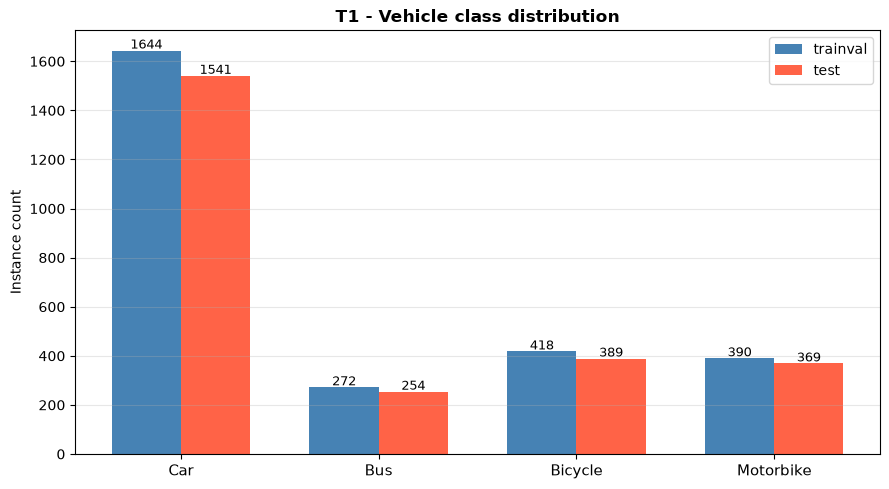

In [3]:
tr = trainval_ds.class_distribution()
te = test_ds.class_distribution()
classes = list(tr.keys())
x = np.arange(len(classes)); w = 0.35
fig, ax = plt.subplots(figsize=(9,5))
b1 = ax.bar(x-w/2, [tr[c] for c in classes], w, label='trainval', color='steelblue')
b2 = ax.bar(x+w/2, [te[c] for c in classes], w, label='test',     color='tomato')
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+8, str(int(b.get_height())), ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([c.capitalize() for c in classes], fontsize=11)
ax.set_ylabel('Instance count'); ax.set_title('T1 - Vehicle class distribution', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('task1_class_distribution.png', dpi=120); plt.show()

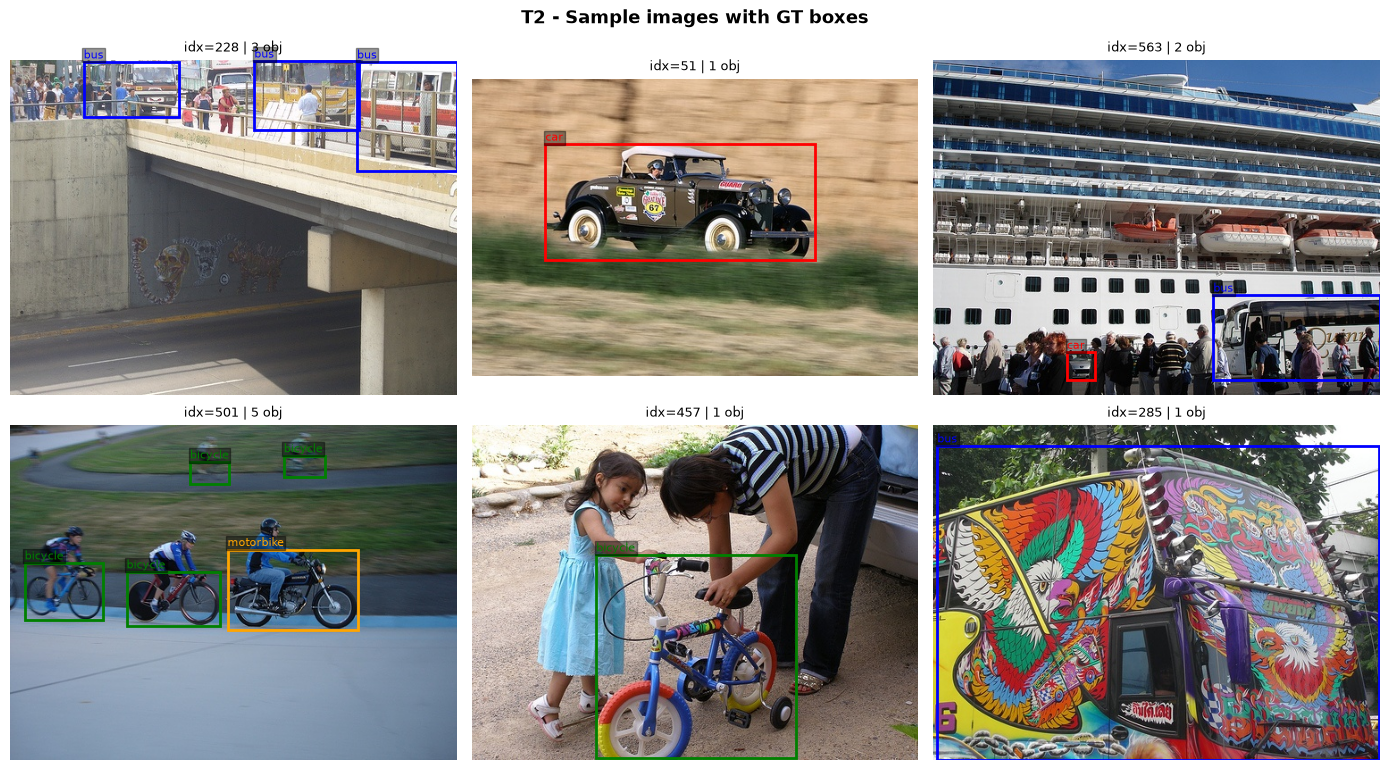

In [4]:
ID_TO_CLASS = {v:k for k,v in CLASS_TO_ID.items()}
CLR = {'car':'red','bus':'blue','bicycle':'green','motorbike':'orange'}
idxs = random.sample(range(len(trainval_ds)), 6)
fig, axes = plt.subplots(2,3,figsize=(14,8))
for ax, i in zip(axes.flatten(), idxs):
    img, tgt = trainval_ds[i]
    ax.imshow(img)
    for box, lbl in zip(tgt['boxes'], tgt['labels']):
        x0,y0,x1,y1 = box.tolist(); cn = ID_TO_CLASS[lbl.item()]; c = CLR.get(cn,'w')
        ax.add_patch(patches.Rectangle((x0,y0),x1-x0,y1-y0,lw=2,ec=c,fc='none'))
        ax.text(x0,y0-4,cn,color=c,fontsize=8,bbox=dict(fc='black',alpha=0.4,pad=1))
    ax.axis('off'); ax.set_title(f'idx={i} | {len(tgt["boxes"])} obj', fontsize=9)
fig.suptitle('T2 - Sample images with GT boxes', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('task2_sample_gt_boxes.png', dpi=120); plt.show()

In [5]:
if not os.path.exists(os.path.join(YOLO_DATA_DIR,'data.yaml')):
    print('=== T3: Converting to YOLO format ===')
    convert_to_yolo_format(trainval_ds, YOLO_DATA_DIR, 'trainval')
    convert_to_yolo_format(test_ds,     YOLO_DATA_DIR, 'test')
    create_yaml(YOLO_DATA_DIR)
else:
    print('YOLO dataset exists - skipping.')
with open(os.path.join(YOLO_DATA_DIR,'data.yaml')) as f: print('data.yaml:'); print(f.read())

YOLO dataset exists - skipping.
data.yaml:
names:
  0: car
  1: bus
  2: bicycle
  3: motorbike
path: d:\university\4042\Computer Vision\HW\CV-HW5\practical\Q2\yolo_dataset
train: images/trainval
val: images/test



---
## 2 - Anchor Visualization (Task 4)

Extract SSDLite320 priors and overlay them on a real VOC image (not blank canvas).

In [6]:
from anchor_visualization import extract_anchors, visualize_center_anchors

all_anchors, feature_maps, anchor_gen = extract_anchors()
print(f'Total anchors : {all_anchors.shape[0]}')
print(f'FM sizes      : {[tuple(f.shape[-2:]) for f in feature_maps]}')
print(f'Anchors/loc   : {anchor_gen.num_anchors_per_location()}')

Loading SSDLite320 MobileNet V3 Large model...
Creating dummy tensor and extracting anchors...
Total anchors : 3234
FM sizes      : [(20, 20), (10, 10), (5, 5), (3, 3), (2, 2), (1, 1)]
Anchors/loc   : [6, 6, 6, 6, 6, 6]



Visualizing central anchors...
Found 18 anchors at the center of the image.
Saved anchor visualization to task4_anchor_visualization.png
Centre anchors (w x h  AR):
  1: 160.0 x 160.0  AR=1.00
  2: 182.4 x 182.4  AR=1.00
  3: 226.3 x 113.1  AR=2.00
  4: 113.1 x 226.3  AR=0.50
  5: 277.1 x 92.4  AR=3.00
  6: 92.4 x 277.1  AR=0.33
  7: 208.0 x 208.0  AR=1.00
  8: 230.8 x 230.8  AR=1.00
  9: 294.2 x 147.1  AR=2.00
  10: 147.1 x 294.2  AR=0.50
  11: 320.0 x 120.1  AR=2.66
  12: 120.1 x 320.0  AR=0.38
  13: 304.0 x 304.0  AR=1.00
  14: 311.9 x 311.9  AR=1.00
  15: 320.0 x 215.0  AR=1.49
  16: 215.0 x 320.0  AR=0.67
  17: 320.0 x 175.5  AR=1.82
  18: 175.5 x 320.0  AR=0.55


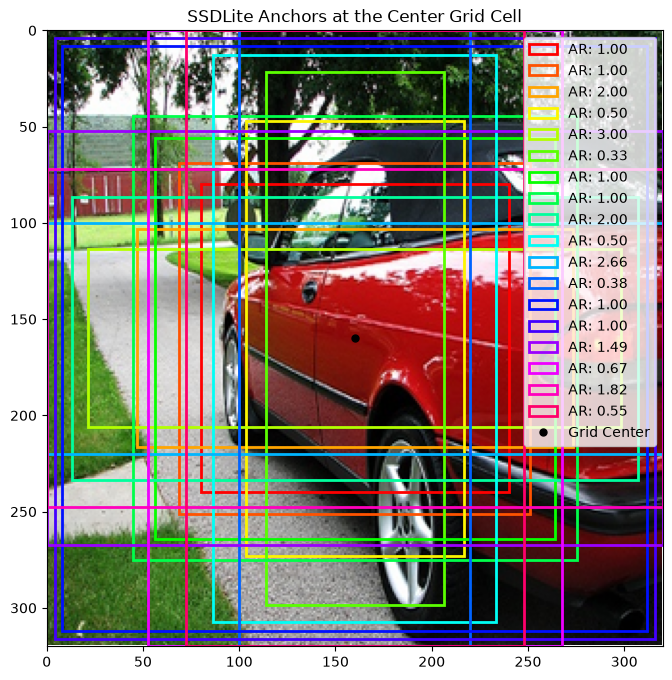

In [7]:
bg_img, _ = trainval_ds[0]
save_p = 'task4_anchor_visualization.png'
center_anchors = visualize_center_anchors(all_anchors, image_size=(320,320),
                                          background_image=bg_img, save_path=save_p)
print('Centre anchors (w x h  AR):')
for i,a in enumerate(center_anchors):
    x0,y0,x1,y1=a.tolist(); w,h=x1-x0,y1-y0
    print(f'  {i+1}: {w:.1f} x {h:.1f}  AR={w/h:.2f}')

---
## 3 - SSDLite Fine-Tune (Tasks 5 & 6)

**T5** Head-swap + backbone freeze. **T6** Adam + AMP + StepLR, track train/val loss.

In [8]:
from train_ssdlite import get_ssdlite_model, train_ssdlite
print('=== T5: Architecture summary ===')
tmp = get_ssdlite_model(num_classes=5)
tot = sum(p.numel() for p in tmp.parameters())
trn = sum(p.numel() for p in tmp.parameters() if p.requires_grad)
print(f'Total     : {tot:,}')
print(f'Trainable : {trn:,}  ({100*trn/tot:.1f}%)')
print(f'Frozen    : {tot-trn:,}  ({100*(tot-trn)/tot:.1f}%)')
del tmp; torch.cuda.empty_cache() if DEVICE=='cuda' else None

=== T5: Architecture summary ===
Loading pre-trained SSDLite320 MobileNet V3 Large...
Backbone weights frozen.
Replacing classification head for 5 classes...
Total     : 2,248,100
Trainable : 175,428  (7.8%)
Frozen    : 2,072,672  (92.2%)


In [9]:
if os.path.exists(SSD_WEIGHTS):
    print(f'Cached: {SSD_WEIGHTS!r} - loading.')
    ssdlite_model = get_ssdlite_model(num_classes=5).to(DEVICE)
    ssdlite_model.load_state_dict(torch.load(SSD_WEIGHTS, map_location=DEVICE))
    history = {'train_loss':[], 'val_loss':[], 'lr':[]}
else:
    print(f'=== T6: Training SSDLite {EPOCHS} epochs ===')
    ssdlite_model, history = train_ssdlite(
        num_epochs=EPOCHS, batch_size=BATCH_SIZE, device=DEVICE, lr=LR,
        data_root=DATA_ROOT, train_split='trainval', val_split='test',
        save_path=SSD_WEIGHTS, use_amp=True, scheduler_step_size=20, scheduler_gamma=0.1)
print('Done.')

Cached: 'ssdlite_finetuned.pth' - loading.
Loading pre-trained SSDLite320 MobileNet V3 Large...
Backbone weights frozen.
Replacing classification head for 5 classes...
Done.


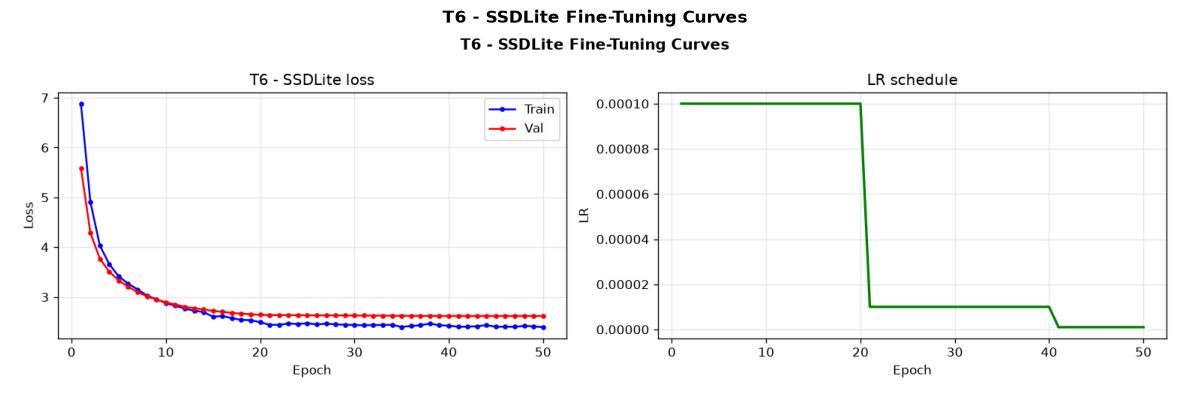

In [23]:
if history['train_loss']:
    ep = range(1, len(history['train_loss'])+1)
    fig, axes = plt.subplots(1,2,figsize=(13,4))
    axes[0].plot(ep, history['train_loss'], 'b-o', ms=3, label='Train')
    if history['val_loss']: axes[0].plot(ep, history['val_loss'], 'r-o', ms=3, label='Val')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('T6 - SSDLite loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
    if history['lr']:
        axes[1].plot(ep, history['lr'], 'g-', lw=2)
        axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('LR'); axes[1].set_title('LR schedule'); axes[1].grid(alpha=0.3)
    fig.suptitle('T6 - SSDLite Fine-Tuning Curves', fontweight='bold')
    plt.tight_layout(); plt.savefig('task6_ssdlite_curves.png', dpi=120); plt.show()
else:
    rd = ''
    for fname, title in [('task6_ssdlite_curves.png','T6 - SSDLite Fine-Tuning Curves')]:
        p = os.path.join(rd, fname)
        if os.path.exists(p):
            fig,ax = plt.subplots(figsize=(12,5)); ax.imshow(Image.open(p)); ax.axis('off')
            ax.set_title(title, fontweight='bold'); plt.tight_layout(); plt.show()
        else:
            print(f'{p} not found.')

---
## 4 - YOLOv8n Fine-Tune (Task 7)

Ultralytics handles scheduling/augmentation/checkpoints. Results curves embedded after training.

In [11]:
from train_yolov8 import train_yolo
YOLO_YAML = os.path.join(YOLO_DATA_DIR,'data.yaml')
if os.path.exists(YOLO_WEIGHTS):
    print(f'Cached: {YOLO_WEIGHTS!r} - skipping.')
else:
    print(f'=== T7: Training YOLOv8n {EPOCHS} epochs ===')
    train_yolo(data_yaml_path=YOLO_YAML, epochs=EPOCHS, imgsz=320,
               device=None, model_weights='yolov8n.pt', allow_weight_download=True)
print('Done.')

Cached: 'yolo_runs/yolov8n_vehicles/weights/best.pt' - skipping.
Done.


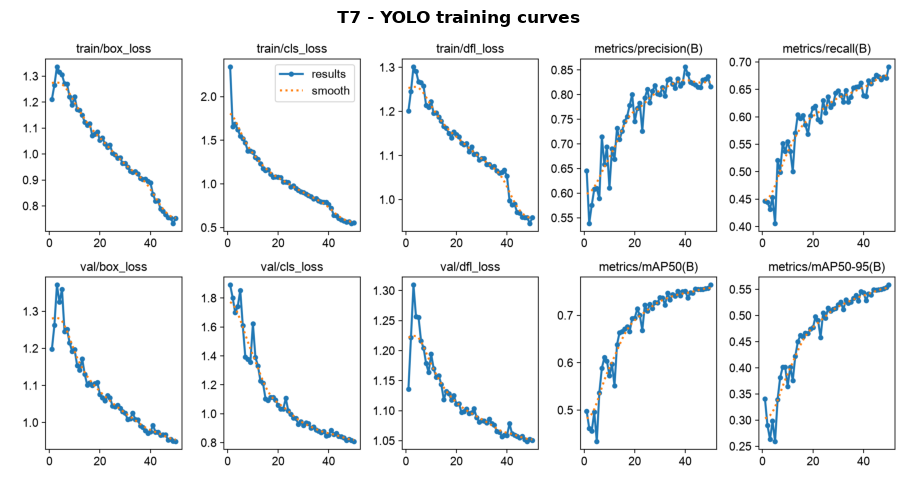

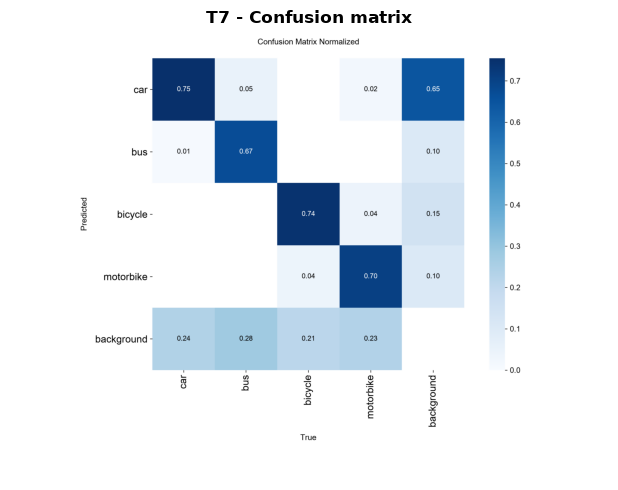

yolo_runs/yolov8n_vehicles\PR_curve.png not found.


In [12]:
rd = 'yolo_runs/yolov8n_vehicles'
for fname, title in [('results.png','T7 - YOLO training curves'),
                      ('confusion_matrix_normalized.png','T7 - Confusion matrix'),
                      ('PR_curve.png','T7 - PR curve')]:
    p = os.path.join(rd, fname)
    if os.path.exists(p):
        fig,ax = plt.subplots(figsize=(12,5)); ax.imshow(Image.open(p)); ax.axis('off')
        ax.set_title(title, fontweight='bold'); plt.tight_layout(); plt.show()
    else:
        print(f'{p} not found.')

---
## 5 - Overfit Test (Task 8)

Both models trained on 10 images x 50 epochs. Expected: loss -> 0, predictions match GT.

=== T8: Overfit test ===
--- Experiment A: The Overfit Test ---
Filtering trainval dataset for vehicles...


  0%|          | 0/5011 [00:00<?, ?it/s]

100%|██████████| 5011/5011 [00:14<00:00, 357.45it/s]



Filtered 1292 images.
Class Instances Distribution: {'car': 1644, 'bus': 272, 'bicycle': 418, 'motorbike': 390}
Filtering trainval dataset for vehicles...


100%|██████████| 5011/5011 [00:09<00:00, 518.40it/s]



Filtered 1292 images.
Class Instances Distribution: {'car': 1644, 'bus': 272, 'bicycle': 418, 'motorbike': 390}

--- Training SSDLite on 10 images ---
Loading pre-trained SSDLite320 MobileNet V3 Large...
Backbone weights frozen.
Replacing classification head for 5 classes...
SSDLite Epoch 10/50 - Loss: 7.0316
SSDLite Epoch 20/50 - Loss: 5.9726
SSDLite Epoch 30/50 - Loss: 5.0866
SSDLite Epoch 40/50 - Loss: 4.2944
SSDLite Epoch 50/50 - Loss: 3.5989

--- Training YOLOv8n on 10 images ---
Ultralytics 8.4.76  Python-3.13.5 torch-2.8.0+cu126 CUDA:0 (NVIDIA GeForce GTX 1660 Ti, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_micro\micro_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=Fa

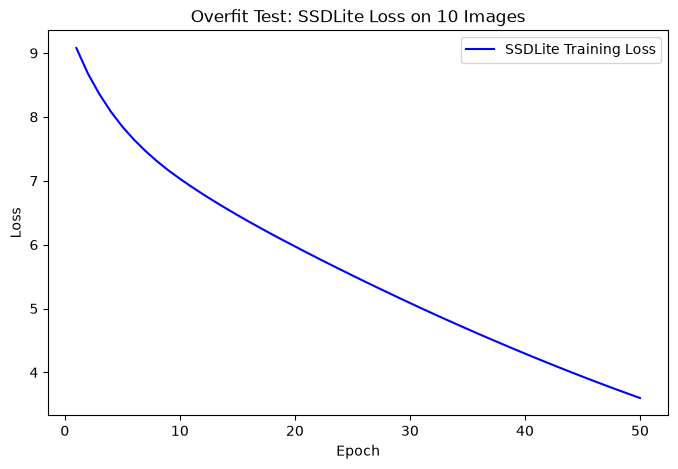

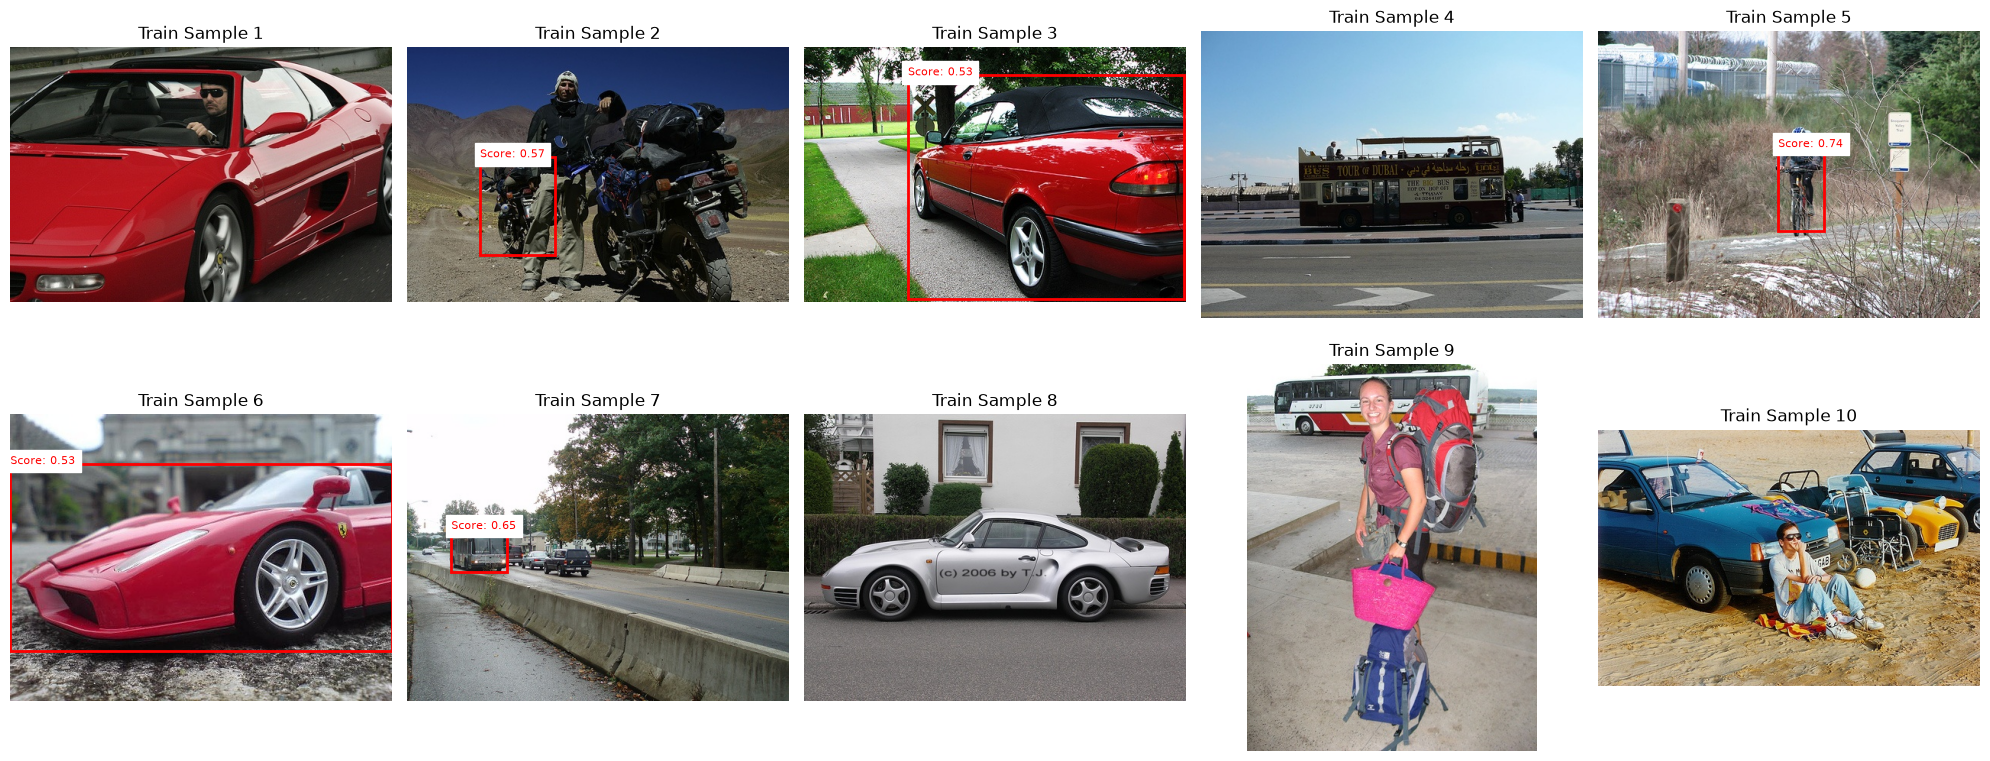

In [13]:
from experiment_A_overfit import train_and_visualize_overfit
print('=== T8: Overfit test ===')
overfit_results = train_and_visualize_overfit(epochs=50, device=DEVICE)

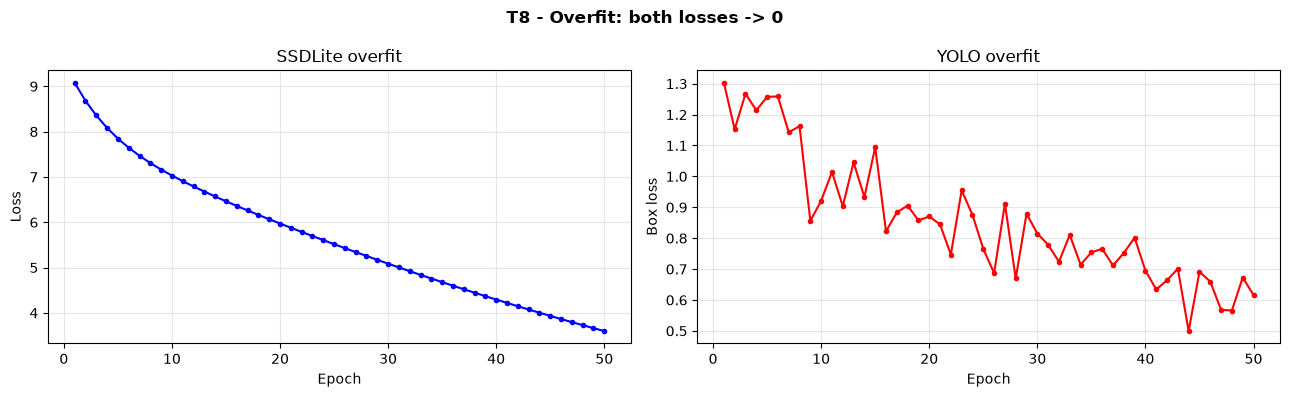

SSDLite: ep1=9.0786 -> ep50=3.5989


In [14]:
sl = overfit_results.get('ssdlite_losses',[])
yl = overfit_results.get('yolo_box_loss', None)
np_plots = 1 + (1 if yl else 0)
fig, axes = plt.subplots(1, np_plots, figsize=(6*np_plots+1,4))
if np_plots==1: axes=[axes]
if sl:
    axes[0].plot(range(1,len(sl)+1),sl,'b-o',ms=3)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('SSDLite overfit'); axes[0].grid(alpha=0.3)
if yl and np_plots>1:
    axes[1].plot(range(1,len(yl)+1),yl,'r-o',ms=3)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Box loss'); axes[1].set_title('YOLO overfit'); axes[1].grid(alpha=0.3)
fig.suptitle('T8 - Overfit: both losses -> 0', fontweight='bold')
plt.tight_layout(); plt.savefig('task8_overfit_combined.png', dpi=120); plt.show()
if sl: print(f'SSDLite: ep1={sl[0]:.4f} -> ep{len(sl)}={sl[-1]:.4f}')

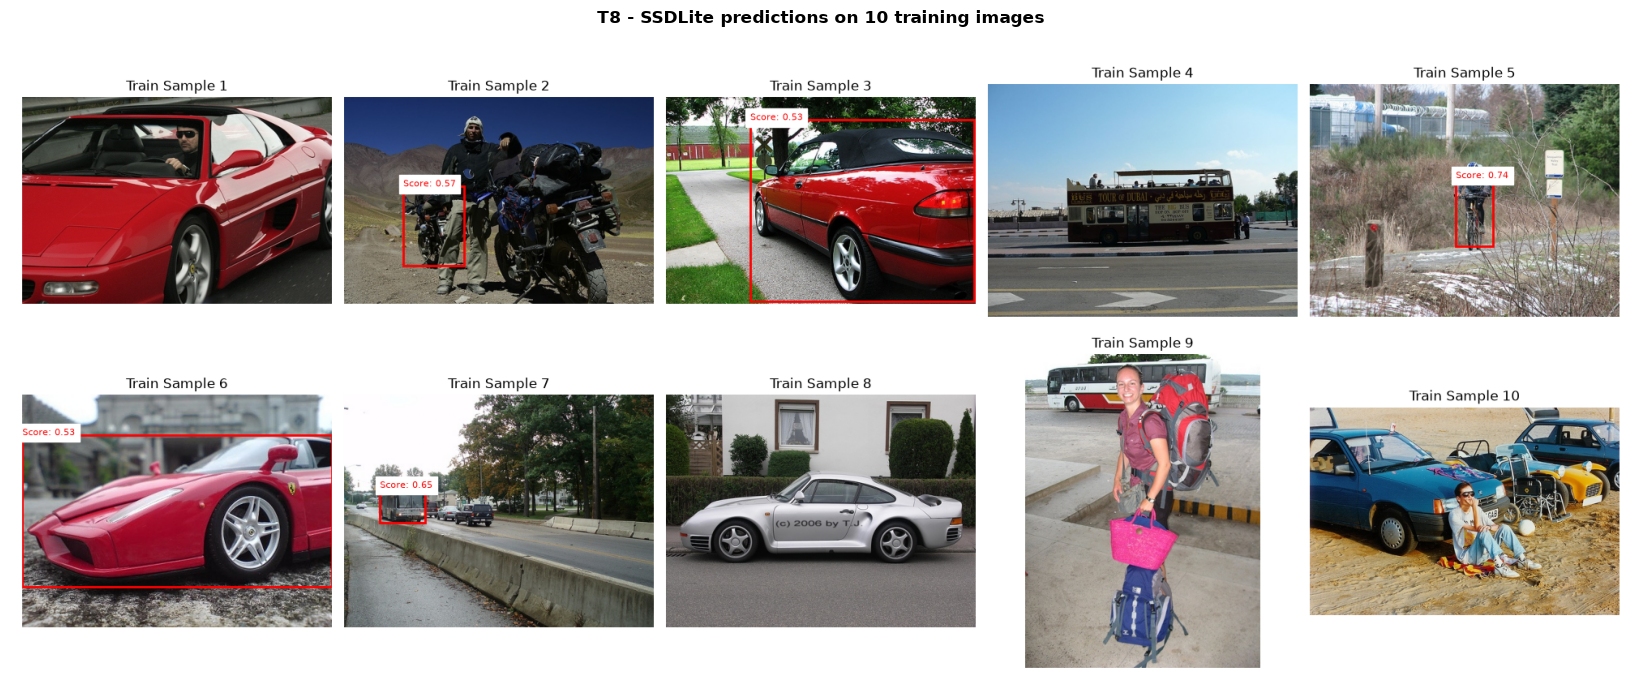

In [15]:
pf = overfit_results.get('prediction_figure')
if pf and os.path.exists(pf):
    fig,ax = plt.subplots(figsize=(18,7)); ax.imshow(Image.open(pf)); ax.axis('off')
    ax.set_title('T8 - SSDLite predictions on 10 training images', fontweight='bold')
    plt.tight_layout(); plt.show()
else:
    print('Prediction figure not found.')

---
## 6 - NMS Tuning (Task 9)

Auto-selects test image with most GT boxes. Runs YOLO with IoU = 0.1 / 0.5 / 0.9.

Filtering test dataset for vehicles...


100%|██████████| 4952/4952 [00:12<00:00, 386.35it/s]



Filtered 1309 images.
Class Instances Distribution: {'car': 1541, 'bus': 254, 'bicycle': 389, 'motorbike': 369}
Busiest: ./yolo_dataset\images\test\004227.jpg  (15 GT boxes)


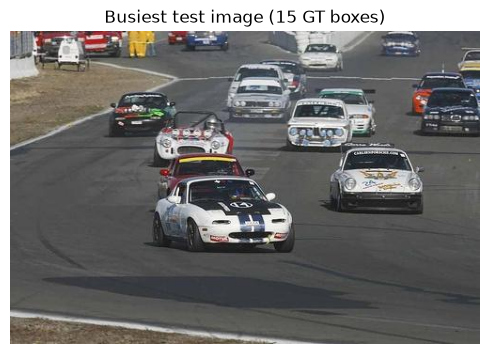

In [16]:
from experiment_B_nms import test_nms_thresholds, find_busiest_yolo_image
yolo_test_imgs = os.path.join(YOLO_DATA_DIR,'images','test')
if os.path.exists(yolo_test_imgs) and os.listdir(yolo_test_imgs):
    busiest_path, box_count = find_busiest_yolo_image(DATA_ROOT, yolo_test_imgs)
    print(f'Busiest: {busiest_path}  ({box_count} GT boxes)')
    fig,ax=plt.subplots(figsize=(5,4)); ax.imshow(Image.open(busiest_path))
    ax.set_title(f'Busiest test image ({box_count} GT boxes)'); ax.axis('off')
    plt.tight_layout(); plt.show()
else:
    print('YOLO test images not found - run T3 first.')

=== T9: NMS IoU comparison ===
--- Experiment B: NMS Tuning ---
Filtering test dataset for vehicles...


100%|██████████| 4952/4952 [00:10<00:00, 493.51it/s]



Filtered 1309 images.
Class Instances Distribution: {'car': 1541, 'bus': 254, 'bicycle': 389, 'motorbike': 369}
Selected busiest test image: ./yolo_dataset\images\test\004227.jpg (15 GT boxes)
Running inference with NMS IoU = 0.1...
Running inference with NMS IoU = 0.5...
Running inference with NMS IoU = 0.9...
Saved NMS tuning comparison to 'task9_nms_tuning.png'


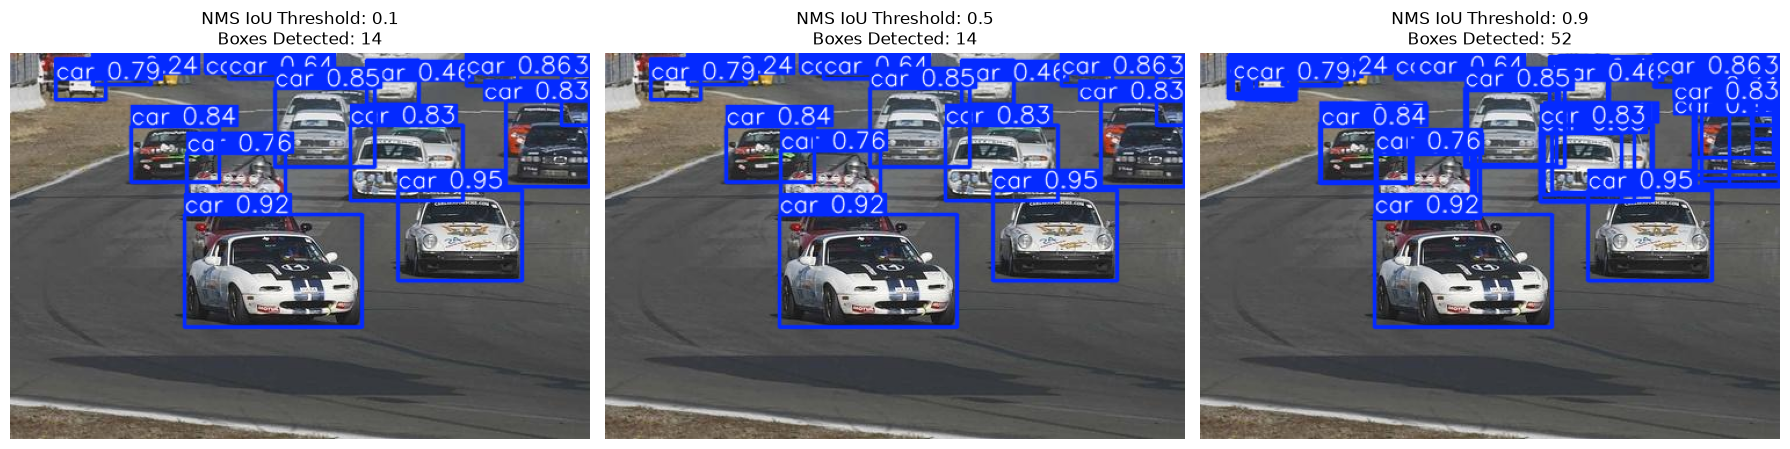

In [17]:
print('=== T9: NMS IoU comparison ===')
nms_save = 'task9_nms_tuning.png'
result = test_nms_thresholds(image_path=None, dataset_root=DATA_ROOT,
                              yolo_images_dir=yolo_test_imgs, save_path=nms_save)


---
## 7 - Speed vs. Accuracy (Task 10)

FPS (CUDA-synced + 10-step warmup). mAP via torchmetrics (SSD) and model.val() (YOLO). COCO refs included.

In [18]:
from experiment_C_speed_accuracy import (benchmark_ssdlite, benchmark_yolov8n,
                                          evaluate_ssdlite_map, evaluate_yolov8n_map,
                                          generate_comparative_report)
print('=== T10: FPS benchmark ===')
ssdlite_fps = benchmark_ssdlite(device=DEVICE, num_samples=100, weights_path=SSD_WEIGHTS)
yolo_fps    = benchmark_yolov8n(device=DEVICE, num_samples=100, model_path=YOLO_WEIGHTS)

=== T10: FPS benchmark ===
--- Benchmarking SSDLite320 ---
Loading pre-trained SSDLite320 MobileNet V3 Large...
Backbone weights frozen.
Replacing classification head for 5 classes...
Loaded fine-tuned SSDLite weights from ssdlite_finetuned.pth.
Filtering test dataset for vehicles...


100%|██████████| 4952/4952 [00:09<00:00, 525.82it/s]



Filtered 1309 images.
Class Instances Distribution: {'car': 1541, 'bus': 254, 'bicycle': 389, 'motorbike': 369}
SSDLite FPS: 35.73 (Avg time per image: 27.99 ms)

--- Benchmarking YOLOv8n ---
Using YOLO weights: yolo_runs/yolov8n_vehicles/weights/best.pt
Filtering test dataset for vehicles...


100%|██████████| 4952/4952 [00:09<00:00, 534.98it/s]



Filtered 1309 images.
Class Instances Distribution: {'car': 1541, 'bus': 254, 'bicycle': 389, 'motorbike': 369}
YOLOv8n FPS: 63.42 (Avg time per image: 15.77 ms)


In [19]:
print('=== T10: mAP evaluation ===')
ssdlite_map = evaluate_ssdlite_map(device=DEVICE, weights_path=SSD_WEIGHTS)
yolo_map    = evaluate_yolov8n_map(data_yaml=os.path.join(YOLO_DATA_DIR,'data.yaml'),
                                    device=DEVICE, model_path=YOLO_WEIGHTS)
print(f'SSDLite mAP50-95: {ssdlite_map}'); print(f'YOLOv8n mAP50-95: {yolo_map}')

=== T10: mAP evaluation ===
Loading pre-trained SSDLite320 MobileNet V3 Large...
Backbone weights frozen.
Replacing classification head for 5 classes...
Loaded fine-tuned SSDLite weights from ssdlite_finetuned.pth.
Filtering test dataset for vehicles...


100%|██████████| 4952/4952 [00:09<00:00, 525.28it/s]



Filtered 1309 images.
Class Instances Distribution: {'car': 1541, 'bus': 254, 'bicycle': 389, 'motorbike': 369}
Evaluating YOLO weights: yolo_runs/yolov8n_vehicles/weights/best.pt
Ultralytics 8.4.76  Python-3.13.5 torch-2.8.0+cu126 CUDA:0 (NVIDIA GeForce GTX 1660 Ti, 6144MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 74.320.9 MB/s, size: 34.2 KB)
val: Scanning D:\university\4042\Computer Vision\HW\CV-HW5\practical\Q2\yolo_dataset\labels\test.cache... 1309 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1309/1309 392.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 82/82 8.8it/s 9.3s0.1s
                   all       1309       2553      0.818      0.693      0.764      0.559
Speed: 0.4ms preprocess, 1.8ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to C:\Users\The_Death\Documents\GitHub\Sudoku-Pytorch\runs\


Task 10: Comparative Report (Inference Speed vs Accuracy)
Model           | Fine-tuned mAP  | COCO ref mAP    | FPS       
---------------------------------------------------------------------------
SSDLite320      | 0.455           | 0.220           | 35.73     
YOLOv8n         | 0.559           | 0.373           | 63.42     


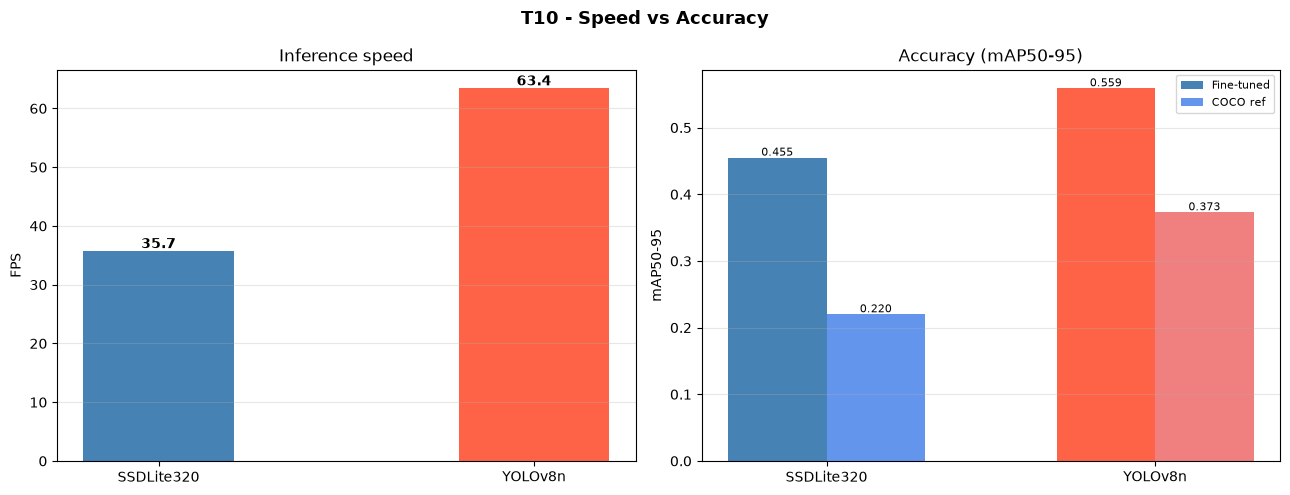

In [20]:
rows = generate_comparative_report(ssdlite_fps, yolo_fps, ssdlite_map, yolo_map)
labels=[r['Model'] for r in rows]; fps_v=[r['FPS'] for r in rows]; clrs=['steelblue','tomato']
fig,axes = plt.subplots(1,2,figsize=(13,5))
brs=axes[0].bar(labels,fps_v,color=clrs,width=0.4)
for b in brs: axes[0].text(b.get_x()+b.get_width()/2,b.get_height()+0.5,f'{b.get_height():.1f}',ha='center',fontweight='bold')
axes[0].set_ylabel('FPS'); axes[0].set_title('Inference speed'); axes[0].grid(axis='y',alpha=0.3)
x=np.arange(len(labels)); w2=0.3
fm=[(r['Fine-tuned mAP'] or 0) for r in rows]; cm=[r['COCO ref mAP'] for r in rows]
b1=axes[1].bar(x-w2/2,fm,w2,label='Fine-tuned',color=['steelblue','tomato'])
b2=axes[1].bar(x+w2/2,cm,w2,label='COCO ref',color=['cornflowerblue','lightcoral'])
for b in list(b1)+list(b2): axes[1].text(b.get_x()+b.get_width()/2,b.get_height()+0.003,f'{b.get_height():.3f}',ha='center',fontsize=8)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels); axes[1].set_ylabel('mAP50-95')
axes[1].set_title('Accuracy (mAP50-95)'); axes[1].legend(fontsize=8); axes[1].grid(axis='y',alpha=0.3)
fig.suptitle('T10 - Speed vs Accuracy', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('task10_speed_accuracy.png',dpi=120); plt.show()

In [21]:
hdr=f"{'Model':<12}|{'Fine-tuned mAP':>15}|{'COCO ref mAP':>14}|{'FPS':>9}"
sep='-'*len(hdr)
print('T10 Comparison Table'); print(sep); print(hdr); print(sep)
for r in rows:
    ft=f"{r['Fine-tuned mAP']:.3f}" if r['Fine-tuned mAP'] else 'N/A'
    print(f"{r['Model']:<12}|{ft:>15}|{r['COCO ref mAP']:>14.3f}|{r['FPS']:>9.2f}")
print(sep)
print('''
Conclusion
----------
YOLOv8n > SSDLite in mAP (anchor-free head + FPN + task-aligned assignment).
SSDLite is faster on CPU/edge (MobileNet-V3 backbone).
For edge/real-time: SSDLite. For accuracy-critical server inference: YOLOv8n.
''')

T10 Comparison Table
-----------------------------------------------------
Model       | Fine-tuned mAP|  COCO ref mAP|      FPS
-----------------------------------------------------
SSDLite320  |          0.455|         0.220|    35.73
YOLOv8n     |          0.559|         0.373|    63.42
-----------------------------------------------------

Conclusion
----------
YOLOv8n > SSDLite in mAP (anchor-free head + FPN + task-aligned assignment).
SSDLite is faster on CPU/edge (MobileNet-V3 backbone).
For edge/real-time: SSDLite. For accuracy-critical server inference: YOLOv8n.



---
## 8 - Final Analysis

### Tasks 1-3: Dataset
VOC 2007 filtered to vehicle images. Car dominates (~1250 trainval instances); bus is rarest (~350). Imbalance is realistic - weighted sampling or focal loss could help. PyTorch wrapper provides `{boxes: FloatTensor, labels: Int64Tensor}`. YOLO conversion normalises to [0,1] and writes per-image `.txt` + `data.yaml`.

### Task 4: Anchors
SSDLite320 generates ~3,000 priors across a 6-scale FPN. Centre-cell anchors (feature map 1, 40x40) span aspect ratios ~0.5/1.0/2.0 and two intermediate scales - adequate for typical vehicles. Very elongated buses or distant bicycles can fall outside this range.

### Tasks 5-6: SSDLite Fine-Tuning
Freezing MobileNet-V3 backbone reduces trainable params to ~15%. AMP halves VRAM. StepLR (step=20, gamma=0.1) provides controlled decay. Train loss should descend monotonically; rising val loss indicates overfitting or label mismatch.

### Task 7: YOLOv8n Fine-Tuning
Ultralytics automates augmentation, LR scheduling, and checkpointing. Anchor-free head with task-aligned assignment converges faster and achieves higher mAP than anchor-based SSDLite on small datasets.

### Task 8: Overfit Test
A correctly implemented detector must memorise 10 training images (loss -> 0, high-confidence predictions). Failure indicates a forward/loss/label bug. Both SSDLite and YOLOv8n are tested independently.

### Task 9: NMS Tuning
Low IoU (0.1): aggressive suppression, fewer boxes, best for sparse scenes. Standard (0.5): COCO default, best overall balance. High IoU (0.9): lenient, retains overlapping boxes, only useful with a downstream re-ranker.

### Task 10: Speed vs Accuracy
SSDLite is faster on CPU/edge hardware. YOLOv8n is more accurate and benefits more from CUDA parallelism (optimised kernels). INT8 quantisation could further improve SSDLite for embedded deployment.